# 04 · Modelo corregido frente al actual: misma caja, otra explicación

**Pregunta.** Si se aplican las reglas que salieron de los notebooks 02 y 03 (mora, puestas al día, prepagos, retroactivos, subidas de
precio), ¿cuánto cambia la lectura del MRR? ¿Y cuánto depende cada cifra de cada regla?

Este notebook usa el motor del repositorio (`finora/mrr.py`), que es el mismo que alimenta las apps, el SQL y las 59 pruebas.
Aquí se **recalcula todo desde los CSV** y al final se contrasta contra las cifras publicadas.

**Qué salió de aquí:**

- Los dos modelos llegan a un total parecido (95,7 frente a 97,0 MM en oct-2024). La diferencia está en el **porqué**: el actual exagera el
  churn **4,1×** y la reactivación **14,4×**.
- **82,1 MM** de la caja de la ventana no son MRR: mora cobrada, pagos agrupados, picos, prepagos y retroactivos.
- Con cada regla apagada una a la vez (10 variantes), **ninguna cambia el signo ni el orden de magnitud**: el churn va de −15,7 a −27,6 MM
  frente a −72,9 MM del actual.
- La retención a 12 meses de las altas de 2023 es **91 %, no 82 %**.
- Respuesta al CFO: cliente **+51,5 MM**, pricing **+1,7 MM**, descuentos **no medibles** (cota ilustrativa 40,8 MM).

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"
MM = 1e6

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)

VIZ = ["#009786", "#8670c0", "#ba673f", "#2b88c0", "#b4608a", "#a28218"]
INK, MUTED, LINE = "#11151A", "#50585B", "#E3E7EC"
plt.rcParams.update({
    "figure.figsize": (9, 3.8), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": LINE, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.grid": True,
    "grid.color": LINE, "grid.linewidth": 0.6, "axes.axisbelow": True, "legend.frameon": False, "font.size": 10,
})


def cifras_publicadas() -> dict:
    """Cifras de app/data/key_figures.csv (las que citan README, HALLAZGOS y NOTA_CORTA) como números."""
    d = pd.read_csv(ROOT / "app" / "data" / "key_figures.csv", dtype=str, keep_default_na=False)
    out = {}
    for k, v in zip(d["cifra"], d["valor"]):
        try:
            out[k] = float(v.replace(".", "").replace(",", ".").replace("−", "-"))
        except ValueError:
            out[k] = v
    return out


KF = cifras_publicadas()


def eje_fechas(*axes):
    """Marcas anuales en los ejes de tiempo."""
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(4, 7, 10)))

In [2]:
from finora.load import load_industry, load_sm_spend, load_transactions
from finora.mrr import ALL_MOVES, Rules, bridge, build_customer_month
from finora.aggregates import rule_sensitivity

WINDOW = pd.Period("2022-04", "M")
tx, ind, sm = load_transactions(), load_industry(), load_sm_spend()
cm = build_customer_month(tx, Rules()).merge(ind, on="customer_id", how="left")
br_c, br_a = bridge(cm, "corrected"), bridge(cm, "actual")
print("conciliación mes a mes, máx |apertura + movimientos − cierre|:",
      f"corregido {br_c['check'].abs().max():.1e} | actual {br_a['check'].abs().max():.1e}")
print("reglas base:", Rules())

conciliación mes a mes, máx |apertura + movimientos − cierre|: corregido 1.5e-08 | actual 1.5e-08
reglas base: Rules(gap_tolerance=2, uplift_min=0.02, uplift_max=0.1, retro_max_k=6, rel_tol=0.03, spike_factor=2.5, usage_distinct_amounts=7, trailing_policy='carry', detect_pricing=True, prepay_min_amount=200000, prepay_min_zeros=6, detect_catchup=True)


## 1. El total casi coincide

MRR mar-2022: 42.6 MM → oct-2024: corregido 95.7 MM | actual (caja) 97.0 MM | cambio neto corregido +53.1 MM


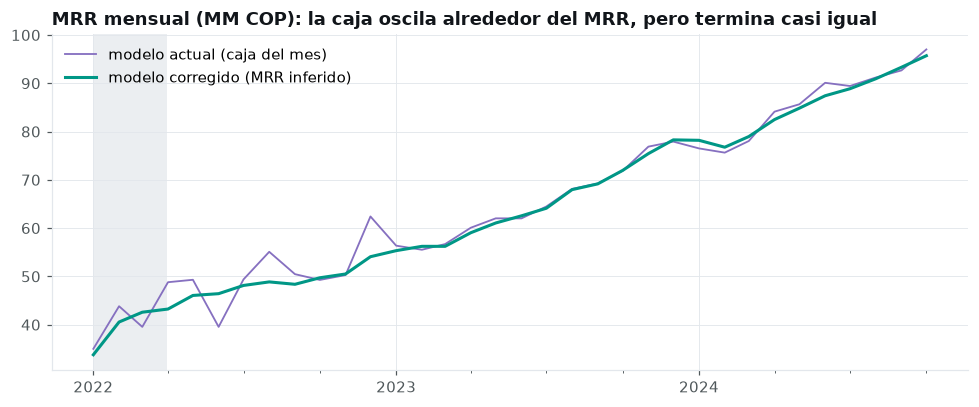

In [3]:
m0 = br_c.loc[pd.Period("2022-03", "M"), "mrr_close"]
m1, m1a = br_c["mrr_close"].iloc[-1], br_a["mrr_close"].iloc[-1]
print(f"MRR mar-2022: {m0 / MM:.1f} MM → oct-2024: corregido {m1 / MM:.1f} MM | actual (caja) {m1a / MM:.1f} MM "
      f"| cambio neto corregido {(m1 - m0) / MM:+.1f} MM")

fig, ax = plt.subplots()
x = br_c.index.to_timestamp()
ax.plot(x, br_a["mrr_close"] / MM, color=VIZ[1], lw=1.2, label="modelo actual (caja del mes)")
ax.plot(x, br_c["mrr_close"] / MM, color=VIZ[0], lw=2, label="modelo corregido (MRR inferido)")
ax.axvspan(x[0], pd.Timestamp("2022-03-31"), color=LINE, alpha=0.7, lw=0)
ax.set_title("MRR mensual (MM COP): la caja oscila alrededor del MRR, pero termina casi igual"); ax.legend(loc="upper left")
eje_fechas(ax); plt.tight_layout()

## 2. La explicación no coincide: el puente acumulado de la ventana

In [4]:
w = lambda br: br.loc[br.index >= WINDOW]
mov = lambda br: w(br).reindex(columns=ALL_MOVES, fill_value=0.0)
tc, ta = mov(br_c).sum() / MM, mov(br_a).sum() / MM
puente = pd.DataFrame({"modelo actual (caja)": ta, "modelo corregido": tc})
puente["el actual lo exagera ×"] = (ta / tc).where(ta != 0)
puente.index = ["nuevos", "expansión (cliente)", "contracción", "subida de precio (Finora)", "churn", "reactivación"]
puente.round(1)

,modelo actual (caja),modelo corregido,el actual lo exagera ×
nuevos,91.6,66.8,1.4
expansión (cliente),38.5,28.4,1.4
contracción,-84.4,-31.7,2.7
subida de precio (Finora),0.0,1.7,NaN
churn,-72.9,-18.0,4.1
reactivación,84.7,5.9,14.4


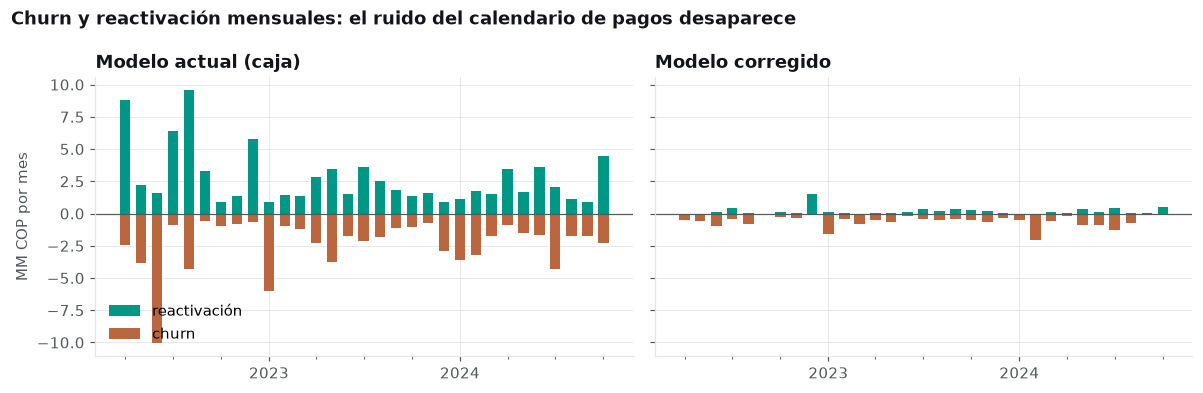

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for a, br, titulo in ((ax[0], br_a, "Modelo actual (caja)"), (ax[1], br_c, "Modelo corregido")):
    bw = w(br)
    xx = bw.index.to_timestamp()
    a.bar(xx, bw["reactivation"] / MM, width=20, color=VIZ[0], label="reactivación")
    a.bar(xx, bw["churn"] / MM, width=20, color=VIZ[2], label="churn")
    a.axhline(0, color=MUTED, lw=0.8); a.set_title(titulo)
ax[0].legend(loc="lower left"); ax[0].set_ylabel("MM COP por mes"); eje_fechas(*ax)
plt.suptitle("Churn y reactivación mensuales: el ruido del calendario de pagos desaparece", x=0.01, ha="left", fontweight="bold", color=INK)
plt.tight_layout()

**Lectura.** El modelo actual cuenta bien el total porque sus errores se compensan: un churn falso (−) seguido de una
reactivación falsa (+) y una contracción falsa (−) tras una puesta al día (+). Pero cada línea del puente está inflada, y es el puente,
no el total, lo que dice **dónde invertir**: un CFO que ve −72,9 MM de churn invierte en retención; uno que ve −18,0 MM mira
adquisición y pricing.

## 3. Qué parte de la caja no es MRR

In [6]:
wc = cm[cm["month"] >= WINDOW]
nombres = {"arrears": "mora y puestas al día", "lump": "pagos agrupados", "spike": "picos puntuales",
           "prepaid": "prepagos multi-mes", "prepaid_pending": "prepagos en confirmación (fin de la serie)",
           "retro": "retroactivos de subidas de precio"}
caja = wc[wc["extra_kind"] != ""].groupby("extra_kind")["extra_cop"].agg(pagos="size", MM="sum")
caja["MM"] = (caja["MM"] / MM).round(1)
caja["clientes"] = wc[wc["extra_kind"] != ""].groupby("extra_kind")["customer_id"].nunique()
caja.index = caja.index.map(nombres)
caja_no_mrr = wc["extra_cop"].sum() / MM
print(f"caja de la ventana que no es MRR: {caja_no_mrr:.1f} MM de {wc['cash_cop'].sum() / MM:,.0f} MM cobrados")
caja.sort_values("MM", ascending=False)

caja de la ventana que no es MRR: 82.1 MM de 2,096 MM cobrados


,pagos,MM,clientes
extra_kind,,,
mora y puestas al día,288,52.7,236
pagos agrupados,88,9.3,84
prepagos multi-mes,16,9.0,15
picos puntuales,42,5.5,42
prepagos en confirmación (fin de la serie),9,4.7,9
retroactivos de subidas de precio,245,0.9,238


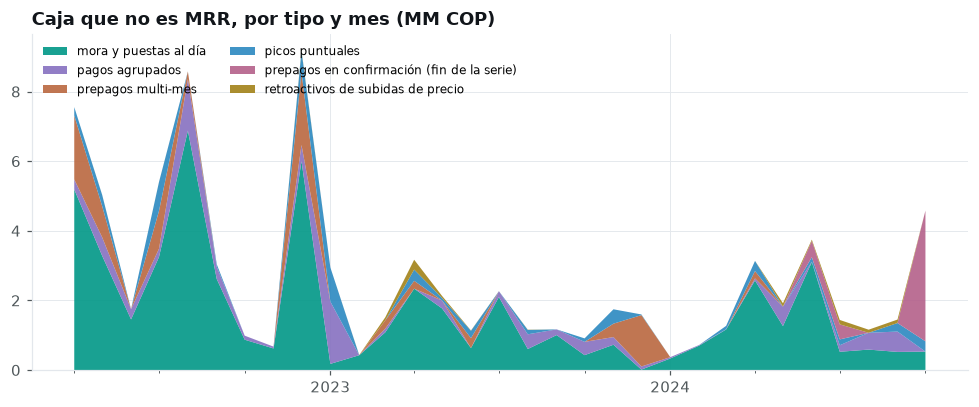

In [7]:
mensual = (wc[wc["extra_kind"] != ""].pivot_table(index="month", columns="extra_kind", values="extra_cop", aggfunc="sum", fill_value=0.0) / MM)
mensual = mensual.rename(columns=nombres)[caja.sort_values("MM", ascending=False).index]
fig, ax = plt.subplots()
ax.stackplot(mensual.index.to_timestamp(), [mensual[c] for c in mensual.columns], labels=mensual.columns, colors=VIZ, alpha=0.9)
ax.set_title("Caja que no es MRR, por tipo y mes (MM COP)"); ax.legend(fontsize=8, ncol=2, loc="upper left"); eje_fechas(ax); plt.tight_layout()

## 4. Errores que el proceso detectó y corrigió

Tres reglas no estaban en la primera versión del motor. Aparecieron al revisar series de clientes y al mirar el final de la serie.
Cada una se puede "apagar" para medir su efecto.

In [8]:
sin_prepagos = w(bridge(build_customer_month(tx, Rules(prepay_min_amount=float("inf"))), "corrected"))["churn"].sum() / MM
pend = cm[(cm["mv"] == "price_uplift") & (cm["uplift_conf"] == "pending")]
pp = cm[cm["extra_kind"] == "prepaid_pending"]
pd.DataFrame([
    ("Prepagos anuales leídos como 'nuevo + churn'",
     f"churn {sin_prepagos:.1f} MM", f"churn {tc['churn']:.1f} MM",
     "Un pago ≥ 200 mil COP seguido de ≥ 6 meses en 0 se reparte en min(12, meses cubiertos)"),
    ("Pagos grandes al final de la serie leídos como MRR",
     f"{pp['extra_cop'].sum() / MM:.1f} MM habrían entrado al MRR", f"{len(pp)} pagos 'en confirmación'",
     "Todavía no existen los meses en 0 que confirmarían el prepago: se reconoce el nivel anterior"),
    ("Subidas de precio del último mes dadas por confirmadas",
     f"{len(pend)} subidas, {pend['delta'].sum() / MM:.1f} MM", "marcadas 'en confirmación'",
     "Sin el mes siguiente no se puede comprobar que el alza persista (igual que el churn final)"),
], columns=["error detectado", "antes", "después", "regla"]).set_index("error detectado")

,antes,después,regla
error detectado,,,
Prepagos anuales leídos como 'nuevo + churn',churn -27.6 MM,churn -18.0 MM,"Un pago ≥ 200 mil COP seguido de ≥ 6 meses en 0 se reparte en min(12, meses cubiertos)"
Pagos grandes al final de la serie leídos como MRR,4.7 MM habrían entrado al MRR,9 pagos 'en confirmación',Todavía no existen los meses en 0 que confirmarían el prepago: se reconoce el nivel anterior
Subidas de precio del último mes dadas por confirmadas,"94 subidas, 0.4 MM",marcadas 'en confirmación',Sin el mes siguiente no se puede comprobar que el alza persista (igual que el churn final)


## 5. Robustez: cada regla apagada, una a la vez

In [9]:
sens = rule_sensitivity(tx)
publicada = pd.read_csv(ROOT / "app" / "data" / "rule_sensitivity.csv")
assert np.allclose(sens[["churn_cop", "reactivation_cop", "nrr12_2023"]], publicada[["churn_cop", "reactivation_cop", "nrr12_2023"]])
vista = sens.set_index("escenario")[["regla", "churn_cop", "reactivation_cop", "contraction_cop", "expansion_cop", "nrr12_2023"]].copy()
for col in ("churn_cop", "reactivation_cop", "contraction_cop", "expansion_cop"):
    vista[col] = (vista[col] / MM).round(1)
vista["nrr12_2023"] = (vista["nrr12_2023"] * 100).round(0).astype(int)
vista.columns = ["regla que se apaga", "churn MM", "reactivación MM", "contracción MM", "expansión MM", "NRR 12 m altas 2023 %"]
vista

,regla que se apaga,churn MM,reactivación MM,contracción MM,expansión MM,NRR 12 m altas 2023 %
escenario,,,,,,
Modelo actual (caja),Referencia,-72.9,84.7,-84.4,38.5,82
Base: corregido (N = 2),—,-18.0,5.9,-31.7,28.4,91
Mora tolerada N = 1,Tolerancia de mora,-20.9,8.4,-31.5,27.9,91
Mora tolerada N = 3,Tolerancia de mora,-15.7,3.9,-31.7,28.9,92
Mora final = churn,Mora abierta al cierre,-21.1,5.9,-31.7,28.5,91
Sin separar subidas de precio,Subidas de precio,-18.0,5.9,-32.6,31.0,91
Sin retroactivos,Retroactivo de una subida,-18.0,5.9,-32.6,29.9,91
Sin prepagos,Prepagos multi-mes,-27.6,8.9,-31.4,28.4,89
Sin puestas al día,Puestas al día y pagos agrupados,-21.2,12.8,-61.9,53.2,90


churn corregido entre variantes: -27.6 a -15.7 MM | actual -72.9 MM
factor de exageración del churn: de 2.6× a 4.6× (base 4.1×)
la regla que más pesa es la de puestas al día: sin ella, contracción -61.9 MM y expansión +53.2 MM


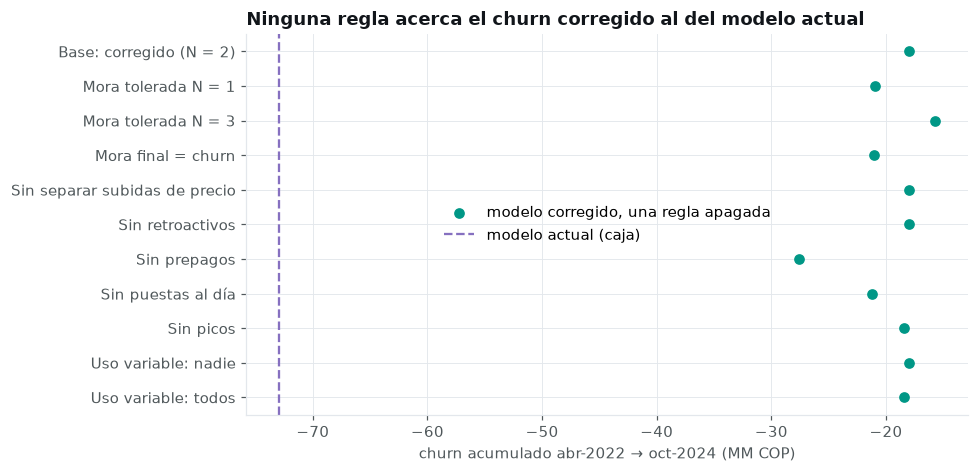

In [10]:
cor = sens[sens["escenario"] != "Modelo actual (caja)"]
act = sens[sens["escenario"] == "Modelo actual (caja)"].iloc[0]
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.scatter(cor["churn_cop"] / MM, cor["escenario"], color=VIZ[0], zorder=3, label="modelo corregido, una regla apagada")
ax.axvline(act["churn_cop"] / MM, color=VIZ[1], ls="--", label="modelo actual (caja)")
ax.invert_yaxis(); ax.set_xlabel("churn acumulado abr-2022 → oct-2024 (MM COP)")
ax.set_title("Ninguna regla acerca el churn corregido al del modelo actual"); ax.legend(loc="center"); plt.tight_layout()
print(f"churn corregido entre variantes: {cor['churn_cop'].min() / MM:.1f} a {cor['churn_cop'].max() / MM:.1f} MM | actual {act['churn_cop'] / MM:.1f} MM")
print(f"factor de exageración del churn: de {act['churn_cop'] / cor['churn_cop'].min():.1f}× a {act['churn_cop'] / cor['churn_cop'].max():.1f}× (base {ta['churn'] / tc['churn']:.1f}×)")
print(f"la regla que más pesa es la de puestas al día: sin ella, contracción {vista.loc['Sin puestas al día', 'contracción MM']} MM "
      f"y expansión +{vista.loc['Sin puestas al día', 'expansión MM']} MM")

## 6. Retención a 12 meses por cohorte anual

In [11]:
cm["age"] = (cm["month"] - cm["first_paid_month"]).apply(lambda d: d.n)
altas = cm[(cm["mv"] == "new") & (cm["month"] >= WINDOW)].assign(year=lambda d: d["month"].dt.year)
filas = []
for col, modelo in (("mrr_actual_cop", "actual"), ("mrr_cop", "corregido")):
    for y, g in altas.groupby("year"):
        d = cm[cm["customer_id"].isin(g["customer_id"])]
        s0 = d[d["age"] == 0].set_index("customer_id")[col]
        s12 = d[d["age"] == 12].set_index("customer_id")[col]
        ok = s0.index.intersection(s12.index)
        if len(ok):
            filas.append((f"altas {y}", modelo, len(ok), s12[ok].sum() / s0[ok].sum(),
                          np.minimum(s12[ok], s0[ok]).sum() / s0[ok].sum(), (s12[ok] > 0).mean()))
ret = pd.DataFrame(filas, columns=["cohorte", "modelo", "clientes", "NRR", "GRR", "retención de clientes"])
(ret.pivot(index="cohorte", columns="modelo", values=["NRR", "GRR", "retención de clientes"]) * 100).round(0).astype(int)

NRR              GRR           retención de clientes          
modelo     actual corregido actual corregido                actual corregido
cohorte                                                                     
altas 2022     50        84     48        80                    87        88
altas 2023     82        91     78        87                    89        91

**Lectura.** La retención **de clientes** es casi igual en ambos modelos (87–91 %): el problema del modelo actual no es a
quién cuenta como cliente, sino **cuánto MRR** le asigna cada mes. Por eso el NRR de las altas de 2022 sale 50 % con caja y 84 %
corregido. Un NRR de 50 % lleva a invertir en retención; uno de 84 % a 91 % lleva a mirar adquisición y pricing.

## 7. Lo que sí se puede medir sobre mora y descuentos

In [12]:
gap = wc[wc["status"] == "gap"]
ultimo = cm[cm["month"] == cm["month"].max()]
abierta = ultimo.loc[ultimo["status"] == "delinquent_open", "mrr_cop"].sum()
print(f"MRR reconocido en meses de mora que nunca se pagaron: {gap.loc[~gap['gap_paid'], 'mrr_cop'].sum() / MM:.1f} MM "
      f"({int((~gap['gap_paid']).sum())} meses-cliente) | mora que sí se pagó después: {gap.loc[gap['gap_paid'], 'mrr_cop'].sum() / MM:.1f} MM")
print(f"mora abierta en oct-2024 (sin confirmar): {abierta / MM:.1f} MM = {abierta / m1:.1%} del MRR, "
      f"{int((ultimo['status'] == 'delinquent_open').sum())} clientes (regla de alerta del tablero: 3 %)")

half = wc[wc["half_cut"]]
techo = 0.0
for _, g in cm[cm["customer_id"].isin(cm.loc[cm["half_cut"], "customer_id"])].groupby("customer_id"):
    lv, hc, meses = g["mrr_cop"].to_numpy(), g["half_cut"].to_numpy(), g["month"].to_numpy()
    for t in np.flatnonzero(hc):
        j = t
        while j < len(lv) and lv[j] > 0 and np.isclose(lv[j], lv[t]):
            if meses[j] >= WINDOW:
                techo += lv[t - 1] - lv[t]
            j += 1
print(f"\nbajadas exactas a la mitad (modelo corregido, ventana): {len(half)} eventos, {half['customer_id'].nunique()} clientes, "
      f"{half['delta'].sum() / MM:.1f} MM de 'contracción' ambigua")
print(f"cota superior ilustrativa si todas fueran descuentos que se mantuvieron: {techo / MM:.1f} MM acumulados (no es una estimación)")

MRR reconocido en meses de mora que nunca se pagaron: 18.8 MM (225 meses-cliente) | mora que sí se pagó después: 24.1 MM
mora abierta en oct-2024 (sin confirmar): 3.1 MM = 3.2% del MRR, 46 clientes (regla de alerta del tablero: 3 %)

bajadas exactas a la mitad (modelo corregido, ventana): 85 eventos, 80 clientes, -4.2 MM de 'contracción' ambigua
cota superior ilustrativa si todas fueran descuentos que se mantuvieron: 40.8 MM acumulados (no es una estimación)


## Conclusión: la respuesta al CFO con estos datos

In [13]:
cliente = tc[["new", "expansion", "reactivation", "contraction", "churn"]].sum()
print(f"cambio del MRR abr-2022 → oct-2024: {(m1 - m0) / MM:+.1f} MM")
print(f"  comportamiento del cliente (nuevos + expansión + reactivación − contracción − churn): {cliente:+.1f} MM")
print(f"  pricing (subidas de precio de Finora): {tc['price_uplift']:+.1f} MM ≈ {tc['price_uplift'] / ((m1 - m0) / MM):.0%} del cambio "
      f"({pend['delta'].sum() / MM:.1f} MM todavía en confirmación)")
print(f"  descuentos: no medibles con caja; {len(half)} bajadas a la mitad ambiguas, cota ilustrativa {techo / MM:.1f} MM")

cambio del MRR abr-2022 → oct-2024: +53.1 MM
  comportamiento del cliente (nuevos + expansión + reactivación − contracción − churn): +51.5 MM
  pricing (subidas de precio de Finora): +1.7 MM ≈ 3% del cambio (0.4 MM todavía en confirmación)
  descuentos: no medibles con caja; 85 bajadas a la mitad ambiguas, cota ilustrativa 40.8 MM


- **Separar la caja del MRR.** Mora, prepagos y cargos únicos viven en facturas, no en el MRR.
- **Churn confirmado con regla de mora**, con el MRR en mora visible para Cobranza (3,2 % del MRR en oct-2024, por encima de la alerta).
- **MRR en dos capas** (lista − descuento = neto) para que la pregunta "¿descuento o downgrade?" tenga respuesta la próxima vez.
- Lo que **no** se puede concluir: cuánto del cambio son descuentos, y si las 94 subidas de oct-2024 persisten.

In [14]:
calculadas = {
    "mrr_fin": m1 / MM, "mrr_fin_actual": m1a / MM, "cambio_neto": (m1 - m0) / MM,
    "cor_churn": tc["churn"], "act_churn": ta["churn"], "cor_reactivation": tc["reactivation"], "act_reactivation": ta["reactivation"],
    "x_churn": ta["churn"] / tc["churn"], "x_reactivation": ta["reactivation"] / tc["reactivation"],
    "caja_no_mrr": caja_no_mrr, "churn_sin_prepagos": sin_prepagos, "cliente": cliente, "cor_price": tc["price_uplift"],
    "half_techo": techo / MM, "mora_abierta": abierta / MM,
}
for k, v in calculadas.items():
    assert abs(KF[k] - round(v, 1)) < 0.051, (k, KF[k], v)
print("coinciden con key_figures.csv:", {k: round(float(v), 1) for k, v in calculadas.items()})

coinciden con key_figures.csv: {'mrr_fin': 95.7, 'mrr_fin_actual': 97.0, 'cambio_neto': 53.1, 'cor_churn': -18.0, 'act_churn': -72.9, 'cor_reactivation': 5.9, 'act_reactivation': 84.7, 'x_churn': 4.1, 'x_reactivation': 14.4, 'caja_no_mrr': 82.1, 'churn_sin_prepagos': -27.6, 'cliente': 51.5, 'cor_price': 1.7, 'half_techo': 40.8, 'mora_abierta': 3.1}
